# Check Reinit Circles (rho=256/266/276)

This notebook checks circle interface evolution on the square domain `[-1, 1] x [-1, 1]` for the first 10 radii (`radius_idx=0..9`) at each resolution.

- Blue: initial analytic SDF circle contour (`phi_sdf=0`)
- Yellow: interface points after 5-step reinitialization from non-SDF field
- Purple: interface points after 10-step reinitialization from non-SDF field

Notes:
- `train_rho*.h5` currently has `blueprint_idx=-1` for all samples, so this check uses deterministic regeneration from the same formulas/seed rules in `data_generate.ipynb`.


In [1]:
import numpy as np
import h5py
import matplotlib.pyplot as plt
from pathlib import Path


In [2]:
# Configuration
RHOS = [256, 266, 276]
SEED = 42
VARIATIONS = 5
SELECT_RADIUS_IDXS = list(range(90, 100))  # fixed larger radii

COLORS = {
    "init": "blue",
    "re5": "yellow",
    "re10": "purple",
}

DATA_DIR = Path("data")
OUTPUT_DIR = Path("output_plots")
SAVE_FIGURES = True


SHOW_GRID_POINTS = True
GRID_POINT_SIZE = 0.08
GRID_ALPHA = 0.18
GRID_COLOR = "lightgray"


In [3]:
def load_h5_stats(h5_path):
    h5_path = Path(h5_path)
    with h5py.File(h5_path, "r") as f:
        steps = np.array(f["reinit_steps"][:, 0], dtype=np.int32)
        radius_idx = np.array(f["radius_idx"][:, 0], dtype=np.int32)
        blueprint_idx = np.array(f["blueprint_idx"][:, 0], dtype=np.int32)

    stats = {
        "path": str(h5_path),
        "total_samples": int(steps.shape[0]),
        "unique_steps": sorted(np.unique(steps).tolist()),
        "num_unique_radius_idx": int(np.unique(radius_idx).shape[0]),
        "radius_idx_min": int(np.min(radius_idx)),
        "radius_idx_max": int(np.max(radius_idx)),
        "num_unique_blueprint_idx": int(np.unique(blueprint_idx).shape[0]),
        "blueprint_idx_min": int(np.min(blueprint_idx)),
        "blueprint_idx_max": int(np.max(blueprint_idx)),
    }
    return stats


def print_h5_checks(rhos):
    print("=== H5 consistency check ===")
    for rho in rhos:
        path = DATA_DIR / f"train_rho{rho}.h5"
        if not path.exists():
            print(f"[rho={rho}] MISSING: {path}")
            continue

        stats = load_h5_stats(path)
        ok_steps = all(s in stats["unique_steps"] for s in [0, 5, 10])
        ok_radius = stats["radius_idx_min"] <= 0 and stats["radius_idx_max"] >= 9

        print(
            f"[rho={rho}] total={stats['total_samples']:,} | "
            f"steps={stats['unique_steps']} | "
            f"radius_idx=[{stats['radius_idx_min']}, {stats['radius_idx_max']}] "
            f"(unique={stats['num_unique_radius_idx']}) | "
            f"blueprint_idx=[{stats['blueprint_idx_min']}, {stats['blueprint_idx_max']}] "
            f"(unique={stats['num_unique_blueprint_idx']})"
        )
        print(f"           check steps(0/5/10)={ok_steps}, radius covers 0..9={ok_radius}")


print_h5_checks(RHOS)


=== H5 consistency check ===
[rho=256] total=3,151,720 | steps=[0, 5, 10, 15, 20] | radius_idx=[0, 123] (unique=124) | blueprint_idx=[25600000, 25600619] (unique=620)
           check steps(0/5/10)=True, radius covers 0..9=True
[rho=266] total=3,408,020 | steps=[0, 5, 10, 15, 20] | radius_idx=[0, 128] (unique=129) | blueprint_idx=[26600000, 26600644] (unique=645)
           check steps(0/5/10)=True, radius covers 0..9=True


BlockingIOError: [Errno 11] Unable to synchronously open file (unable to lock file, errno = 11, error message = 'Resource temporarily unavailable')

In [ ]:
def _subseed(global_seed, r_idx, v_idx):
    x = np.uint64(global_seed)
    x ^= np.uint64(1469598103934665603)
    x ^= np.uint64(r_idx + 1) * np.uint64(1099511628211)
    x ^= np.uint64(v_idx + 1) * np.uint64(14029467366897019727)
    return int(x % np.uint64(2**32))


def build_generator_for_rho(rho, seed=42, variations=5):
    rho = int(rho)
    h = 2.0 / (rho - 1)
    r_min = 1.6 * h
    r_max = 1.0 - 2.0 * h
    num_radii = int(np.floor((rho - 8.2) / 2.0)) + 1
    radii_set = np.linspace(r_min, r_max, num_radii, dtype=float)

    return {
        "rho": rho,
        "seed": int(seed),
        "variations": int(variations),
        "h": h,
        "r_min": r_min,
        "r_max": r_max,
        "num_radii": num_radii,
        "radii_set": radii_set,
        "center_min": 0.0 - h / 2.0,
        "center_max": 0.0 + h / 2.0,
    }


def build_blueprint_by_radius(rho, radius_idx, variation_idx=0, seed=42, variations=5):
    gen = build_generator_for_rho(rho, seed=seed, variations=variations)

    radius_idx = int(radius_idx)
    variation_idx = int(variation_idx)

    if radius_idx < 0 or radius_idx >= gen["num_radii"]:
        raise ValueError(f"radius_idx={radius_idx} out of range [0, {gen['num_radii'] - 1}]")
    if variation_idx < 0 or variation_idx >= variations:
        raise ValueError(f"variation_idx={variation_idx} out of range [0, {variations - 1}]")

    r = float(gen["radii_set"][radius_idx])
    sub_seed = _subseed(seed, radius_idx, variation_idx)
    rng = np.random.default_rng(sub_seed)

    cx = float(rng.uniform(gen["center_min"], gen["center_max"]))
    cy = float(rng.uniform(gen["center_min"], gen["center_max"]))

    return {
        "rho": int(rho),
        "h": float(gen["h"]),
        "radius_idx": radius_idx,
        "variation_idx": variation_idx,
        "seed": int(seed),
        "sub_seed": int(sub_seed),
        "radius": r,
        "cx": cx,
        "cy": cy,
    }


def select_10_circles_by_radius(rho):
    circles = []
    for ridx in SELECT_RADIUS_IDXS:
        circles.append(build_blueprint_by_radius(rho, ridx, variation_idx=0, seed=SEED, variations=VARIATIONS))
    return circles


In [ ]:
def build_phi_fields(circle):
    rho = int(circle["rho"])
    h = float(circle["h"])
    r = float(circle["radius"])
    cx = float(circle["cx"])
    cy = float(circle["cy"])

    x = np.linspace(-1.0, 1.0, rho, dtype=np.float64)
    y = np.linspace(-1.0, 1.0, rho, dtype=np.float64)
    X, Y = np.meshgrid(x, y, indexing="ij")

    phi_sdf = np.sqrt((X - cx) ** 2 + (Y - cy) ** 2) - r
    phi_nonsdf = (X - cx) ** 2 + (Y - cy) ** 2 - r**2

    return phi_sdf, phi_nonsdf, h, X, Y


class LevelSetReinitializer:
    """HJ-WENO5 + Godunov + SSP-RK3 reinitialization solver."""

    def __init__(self, cfl=0.5, eps_weno=1e-6, eps_sign_factor=1.0):
        self.cfl = float(cfl)
        self.eps_weno = float(eps_weno)
        self.eps_sign_factor = float(eps_sign_factor)

    def _smoothed_sign(self, phi0, h):
        eps = self.eps_sign_factor * h
        return phi0 / np.sqrt(phi0**2 + eps**2)

    def _hj_weno5_1d(self, v1, v2, v3, v4, v5):
        beta0 = (13.0 / 12.0) * (v1 - 2.0 * v2 + v3) ** 2 + (1.0 / 4.0) * (v1 - 4.0 * v2 + 3.0 * v3) ** 2
        beta1 = (13.0 / 12.0) * (v2 - 2.0 * v3 + v4) ** 2 + (1.0 / 4.0) * (v2 - v4) ** 2
        beta2 = (13.0 / 12.0) * (v3 - 2.0 * v4 + v5) ** 2 + (1.0 / 4.0) * (3.0 * v3 - 4.0 * v4 + v5) ** 2

        alpha0 = 0.1 / (beta0 + self.eps_weno) ** 2
        alpha1 = 0.6 / (beta1 + self.eps_weno) ** 2
        alpha2 = 0.3 / (beta2 + self.eps_weno) ** 2
        sum_alpha = alpha0 + alpha1 + alpha2

        w0 = alpha0 / sum_alpha
        w1 = alpha1 / sum_alpha
        w2 = alpha2 / sum_alpha

        p0 = (1.0 / 3.0) * v1 - (7.0 / 6.0) * v2 + (11.0 / 6.0) * v3
        p1 = -(1.0 / 6.0) * v2 + (5.0 / 6.0) * v3 + (1.0 / 3.0) * v4
        p2 = (1.0 / 3.0) * v3 + (5.0 / 6.0) * v4 - (1.0 / 6.0) * v5

        return w0 * p0 + w1 * p1 + w2 * p2

    def _get_derivatives_weno5(self, phi, h):
        nx, ny = phi.shape
        phi_pad = np.pad(phi, pad_width=3, mode="edge")

        d_x = (phi_pad[:, 1:] - phi_pad[:, :-1]) / h
        d_y = (phi_pad[1:, :] - phi_pad[:-1, :]) / h

        Dx_m = self._hj_weno5_1d(
            d_x[3:-3, 0:ny],
            d_x[3:-3, 1:ny + 1],
            d_x[3:-3, 2:ny + 2],
            d_x[3:-3, 3:ny + 3],
            d_x[3:-3, 4:ny + 4],
        )
        Dx_p = self._hj_weno5_1d(
            d_x[3:-3, 5:ny + 5],
            d_x[3:-3, 4:ny + 4],
            d_x[3:-3, 3:ny + 3],
            d_x[3:-3, 2:ny + 2],
            d_x[3:-3, 1:ny + 1],
        )

        Dy_m = self._hj_weno5_1d(
            d_y[0:nx, 3:-3],
            d_y[1:nx + 1, 3:-3],
            d_y[2:nx + 2, 3:-3],
            d_y[3:nx + 3, 3:-3],
            d_y[4:nx + 4, 3:-3],
        )
        Dy_p = self._hj_weno5_1d(
            d_y[5:nx + 5, 3:-3],
            d_y[4:nx + 4, 3:-3],
            d_y[3:nx + 3, 3:-3],
            d_y[2:nx + 2, 3:-3],
            d_y[1:nx + 1, 3:-3],
        )

        return Dx_m, Dx_p, Dy_m, Dy_p

    @staticmethod
    def _godunov_grad_norm(Dx_m, Dx_p, Dy_m, Dy_p, S0):
        grad_plus = np.sqrt(
            np.maximum(np.maximum(Dx_m, -Dx_p), 0.0) ** 2 + np.maximum(np.maximum(Dy_m, -Dy_p), 0.0) ** 2
        )
        grad_minus = np.sqrt(
            np.maximum(np.maximum(-Dx_m, Dx_p), 0.0) ** 2 + np.maximum(np.maximum(-Dy_m, Dy_p), 0.0) ** 2
        )
        return np.where(S0 >= 0.0, grad_plus, grad_minus)

    def _compute_rhs(self, phi, S0, h):
        Dx_m, Dx_p, Dy_m, Dy_p = self._get_derivatives_weno5(phi, h)
        grad_G = self._godunov_grad_norm(Dx_m, Dx_p, Dy_m, Dy_p, S0)
        return -S0 * (grad_G - 1.0)

    def reinitialize(self, phi0, h, n_steps):
        n_steps = int(n_steps)
        if n_steps <= 0:
            return phi0.copy()

        phi = phi0.astype(np.float64, copy=True)
        S0 = self._smoothed_sign(phi0.astype(np.float64, copy=False), h)
        dt = self.cfl * h

        for _ in range(n_steps):
            L1 = self._compute_rhs(phi, S0, h)
            phi_1 = phi + dt * L1

            L2 = self._compute_rhs(phi_1, S0, h)
            phi_2 = 0.75 * phi + 0.25 * (phi_1 + dt * L2)

            L3 = self._compute_rhs(phi_2, S0, h)
            phi = (1.0 / 3.0) * phi + (2.0 / 3.0) * (phi_2 + dt * L3)

        return phi


def reinitialize(phi0, h, n_steps):
    solver = LevelSetReinitializer(cfl=0.5)
    return solver.reinitialize(phi0, h, n_steps)


def extract_interface_points(phi, X, Y):
    sign_change_x = phi[:-1, :] * phi[1:, :] <= 0.0
    sign_change_y = phi[:, :-1] * phi[:, 1:] <= 0.0

    sign_change_x[0, :] = False
    sign_change_x[-1, :] = False
    sign_change_x[:, 0] = False
    sign_change_x[:, -1] = False

    sign_change_y[0, :] = False
    sign_change_y[-1, :] = False
    sign_change_y[:, 0] = False
    sign_change_y[:, -1] = False

    Ix, Jx = np.where(sign_change_x)
    Iy, Jy = np.where(sign_change_y)

    I = np.concatenate([Ix, Iy])
    J = np.concatenate([Jx, Jy])

    xp = X[I, J]
    yp = Y[I, J]
    return xp, yp


In [ ]:
def plot_resolution_panel(rho, circles, save_path=None):
    fig, axes = plt.subplots(2, 5, figsize=(20, 8), constrained_layout=True)
    axes = axes.ravel()

    total_points_5 = 0
    total_points_10 = 0

    for ax, circle in zip(axes, circles):
        phi_sdf, phi_nonsdf, h, X, Y = build_phi_fields(circle)

        phi_re5 = reinitialize(phi_nonsdf, h, 5)
        phi_re10 = reinitialize(phi_nonsdf, h, 10)

        if SHOW_GRID_POINTS:
            ax.scatter(
                X.ravel(),
                Y.ravel(),
                s=GRID_POINT_SIZE,
                c=GRID_COLOR,
                alpha=GRID_ALPHA,
                linewidths=0,
                zorder=1,
                rasterized=True,
            )

        xp5, yp5 = extract_interface_points(phi_re5, X, Y)
        xp10, yp10 = extract_interface_points(phi_re10, X, Y)

        total_points_5 += int(xp5.shape[0])
        total_points_10 += int(xp10.shape[0])

        ax.contour(X, Y, phi_sdf, levels=[0.0], colors=[COLORS["init"]], linewidths=1.5, zorder=3)
        ax.scatter(xp5, yp5, s=6, c=COLORS["re5"], alpha=0.8, zorder=4)
        ax.scatter(xp10, yp10, s=6, c=COLORS["re10"], alpha=0.8, zorder=5)

        ax.set_xlim(-1.0, 1.0)
        ax.set_ylim(-1.0, 1.0)
        ax.set_aspect("equal", adjustable="box")
        ax.set_title(
            f"rho={rho}, radius_idx={circle['radius_idx']}\n"
            f"r={circle['radius']:.6f}",
            fontsize=10,
        )

    handles = [
        plt.Line2D([0], [0], color=COLORS["init"], lw=2, label="Initial circle (SDF contour)"),
        plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=COLORS["re5"], markersize=6, label="Reinit 5 steps"),
        plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=COLORS["re10"], markersize=6, label="Reinit 10 steps"),
    ]
    fig.legend(handles=handles, loc="upper center", ncol=3, frameon=False)
    fig.suptitle(f"Circle Reinitialization Check (rho={rho}, radius_idx=0..9)", fontsize=14)

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=180, bbox_inches="tight")

    plt.show()

    return {
        "rho": int(rho),
        "num_circles": len(circles),
        "total_interface_points_iter5": int(total_points_5),
        "total_interface_points_iter10": int(total_points_10),
    }


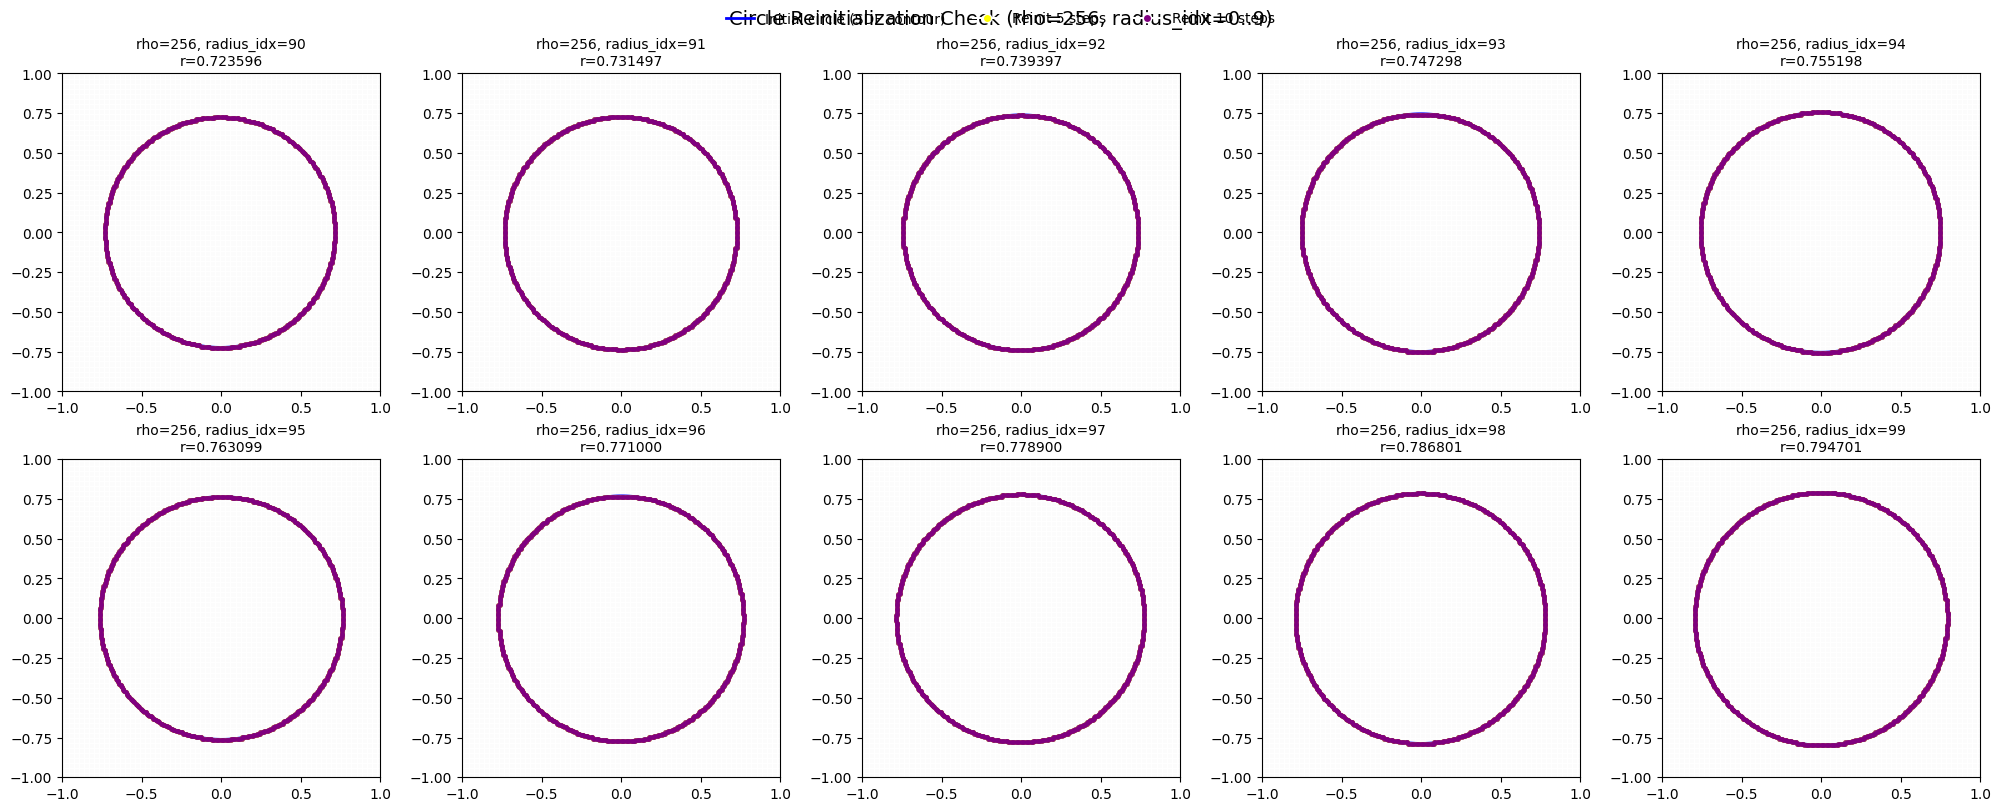

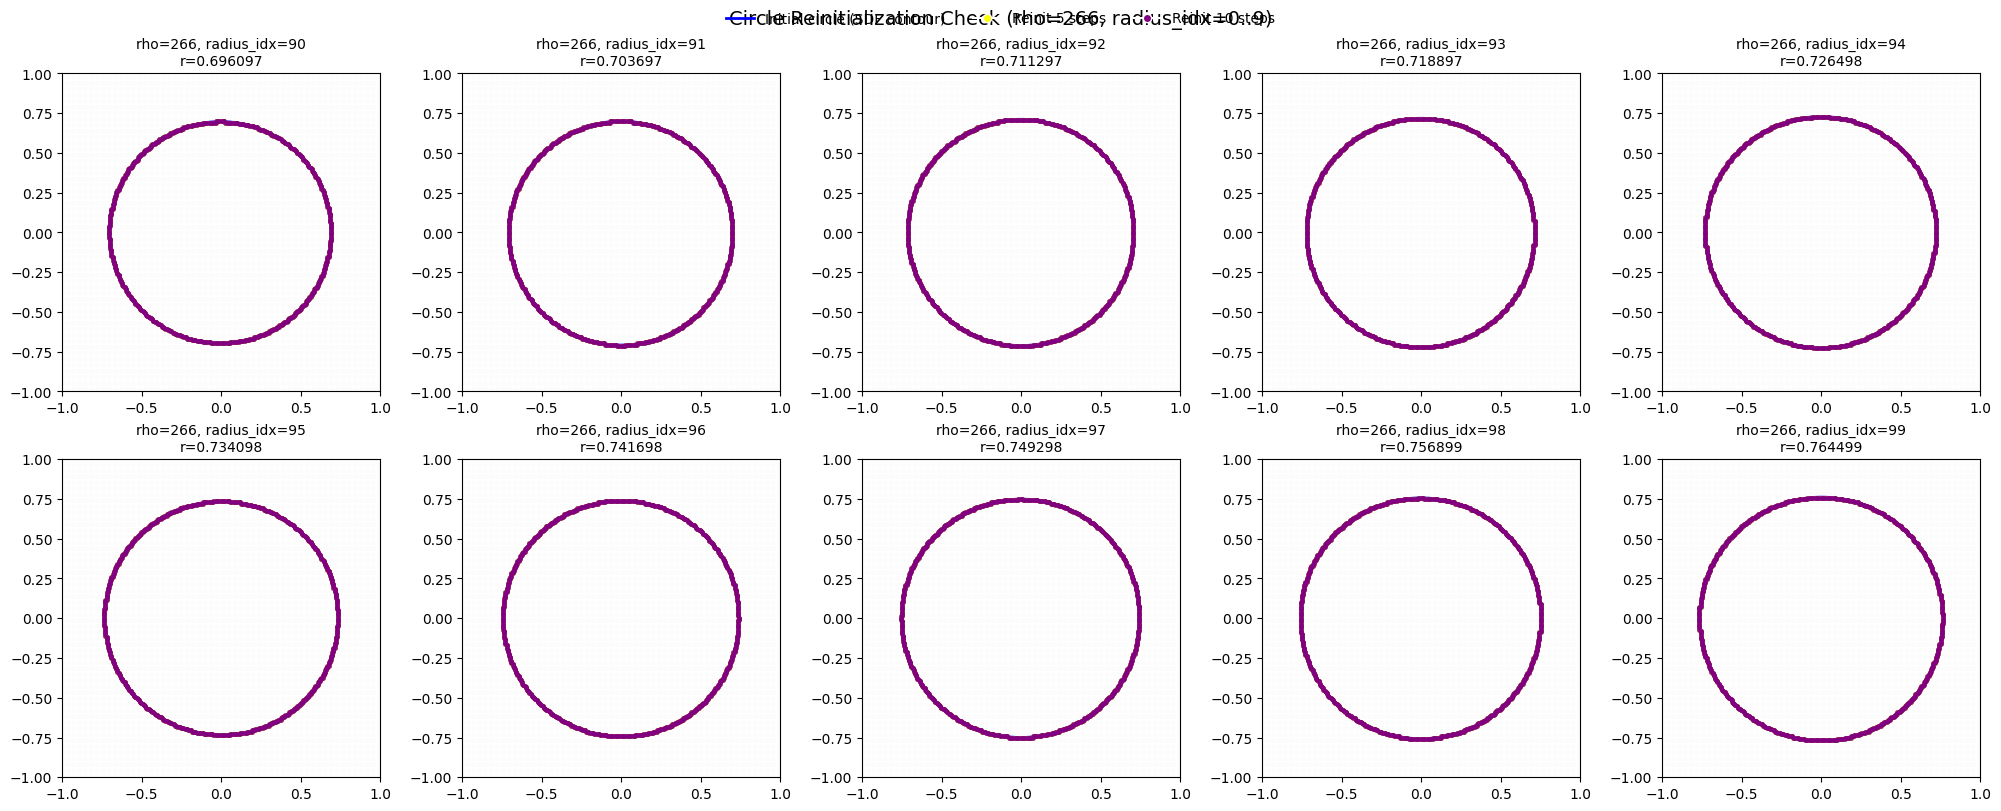

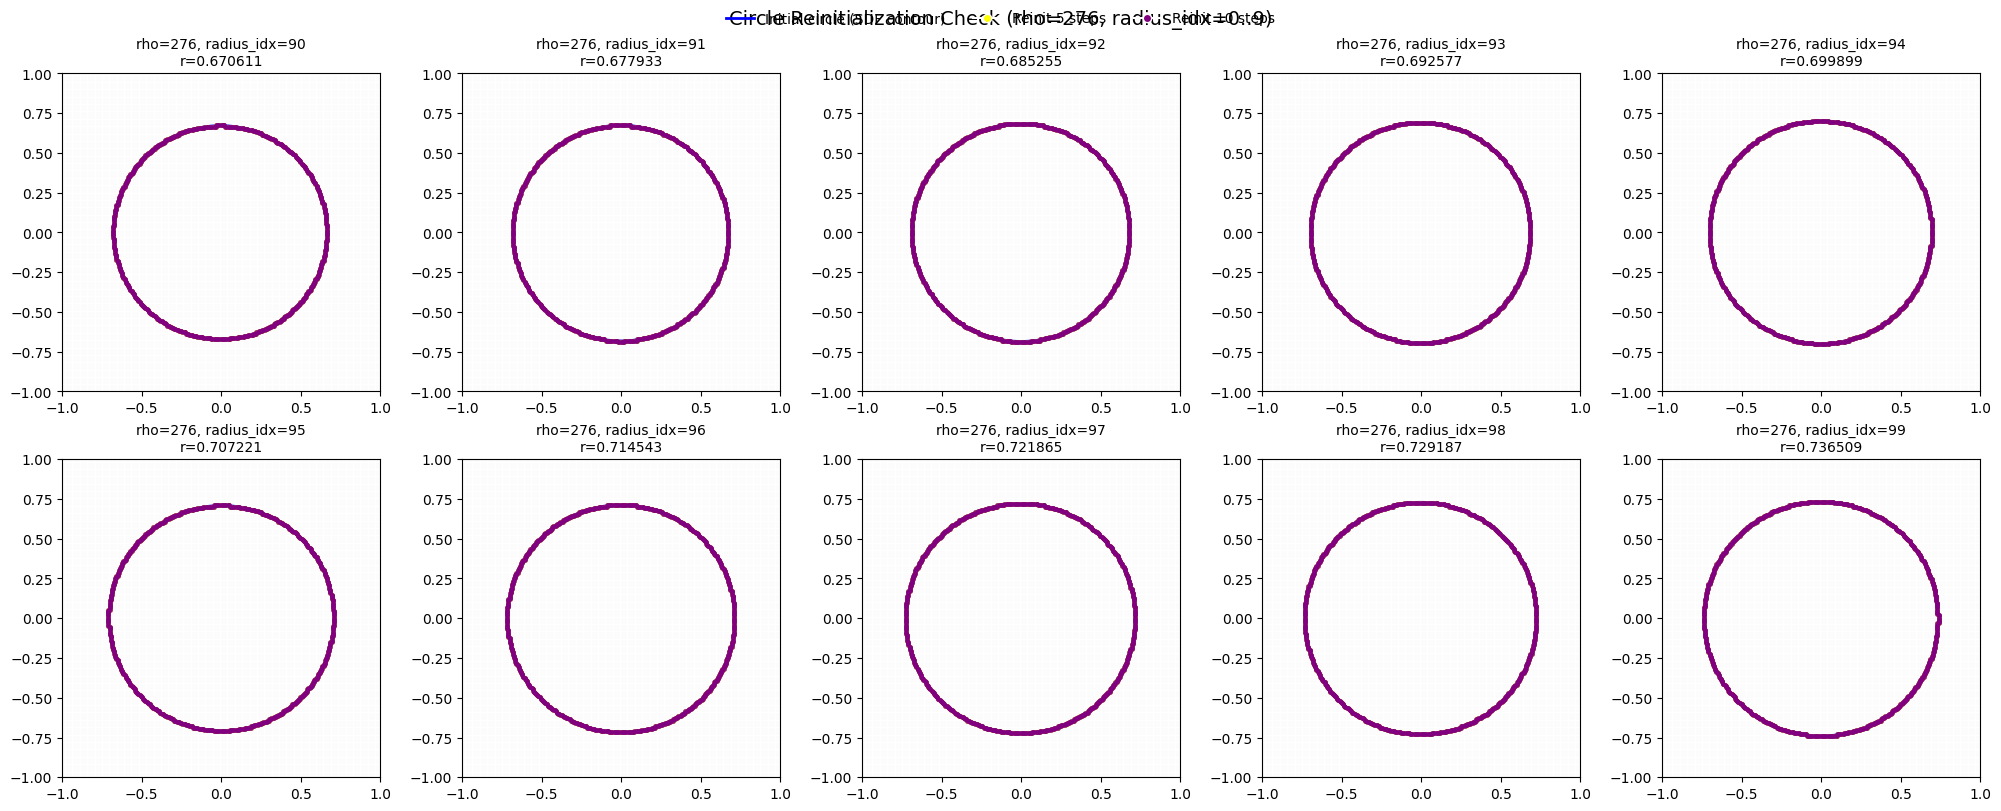

=== Plot summary ===
{'rho': 256, 'num_circles': 10, 'total_interface_points_iter5': 7744, 'total_interface_points_iter10': 7744}
{'rho': 266, 'num_circles': 10, 'total_interface_points_iter5': 7742, 'total_interface_points_iter10': 7742}
{'rho': 276, 'num_circles': 10, 'total_interface_points_iter5': 7734, 'total_interface_points_iter10': 7734}
Saved figures:
output_plots\check_reinit_rho256.png
output_plots\check_reinit_rho266.png
output_plots\check_reinit_rho276.png


In [ ]:
results = []
for rho in RHOS:
    circles = select_10_circles_by_radius(rho)
    save_path = OUTPUT_DIR / f"check_reinit_rho{rho}.png" if SAVE_FIGURES else None
    stats = plot_resolution_panel(rho, circles, save_path=save_path)
    results.append(stats)

print("=== Plot summary ===")
for item in results:
    print(item)

if SAVE_FIGURES:
    print("Saved figures:")
    for rho in RHOS:
        print(OUTPUT_DIR / f"check_reinit_rho{rho}.png")
